# LLM Eval: Movie Remakes Structural Similarity

This notebook:
1. Reads OpenAI API key from `openai_key.txt`
2. Loads eval pairs from `data/eval_data/eval_story_pairs_200.csv`
3. Filters `movie_remakes` pairs
4. Calls `gpt-5` to rate structural similarity from **1 to 10**
5. Saves results to `data/eval_results/movie_remakes_llm_structural_scores.json`


In [1]:
from pathlib import Path
import json
import time
import re
from typing import Any

import pandas as pd
from openai import OpenAI
from tqdm.auto import tqdm

In [2]:
def resolve_project_root(start: Path) -> Path:
    # Walk up from the current working directory and pick the first directory
    # that contains a data/ folder.
    for cand in [start] + list(start.parents):
        if (cand / 'data').exists():
            return cand
    raise FileNotFoundError(
        f"Could not resolve project root from {start}. No parent has a data/ directory."
    )

PROJECT_ROOT = resolve_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data'
EVAL_INPUT_CSV = DATA_DIR / 'eval_data' / 'eval_story_pairs_200.csv'
RESULTS_DIR = DATA_DIR / 'eval_results'
RESULTS_PATH = RESULTS_DIR / 'movie_remakes_llm_structural_scores.json'
KEY_PATH = PROJECT_ROOT / 'openai_key.txt'

MODEL_NAME = 'gpt-5'

REQUEST_SLEEP_SECONDS = 0.25
MAX_RETRIES = 4

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT    :', PROJECT_ROOT)
print('EVAL_INPUT_CSV  :', EVAL_INPUT_CSV)
print('RESULTS_PATH    :', RESULTS_PATH)
print('KEY_PATH        :', KEY_PATH)


PROJECT_ROOT    : /Users/shayan/Projects/NarrativeSimilarity
EVAL_INPUT_CSV  : /Users/shayan/Projects/NarrativeSimilarity/data/eval_data/eval_story_pairs_200.csv
RESULTS_PATH    : /Users/shayan/Projects/NarrativeSimilarity/data/eval_results/movie_remakes_llm_structural_scores.json
KEY_PATH        : /Users/shayan/Projects/NarrativeSimilarity/openai_key.txt


In [3]:
if not KEY_PATH.exists():
    KEY_PATH = PROJECT_ROOT.parent / 'openai_key.txt'

if not KEY_PATH.exists():
    raise FileNotFoundError(f'OpenAI key file not found: {KEY_PATH}')

api_key = KEY_PATH.read_text(encoding='utf-8').strip()
if not api_key:
    raise ValueError(f'OpenAI key file is empty: {KEY_PATH}')

client = OpenAI(api_key=api_key)

print(f'OpenAI client initialized. Key file: {KEY_PATH}')


OpenAI client initialized. Key file: /Users/shayan/Projects/NarrativeSimilarity/openai_key.txt


In [4]:
if not EVAL_INPUT_CSV.exists():
    raise FileNotFoundError(f'Input CSV not found: {EVAL_INPUT_CSV}')

eval_df = pd.read_csv(EVAL_INPUT_CSV)
movie_df = eval_df[eval_df['dataset'] == 'movie_remakes'].copy().reset_index(drop=True)

print('Total rows in eval file:', len(eval_df))
print('Movie remakes rows:', len(movie_df))
movie_df[['pair_id', 'pair_type', 'label']].head()

Total rows in eval file: 200
Movie remakes rows: 100


,pair_id,pair_type,label
0,movie_remakes__0100,random_negative,0
1,movie_remakes__0101,positive,1
2,movie_remakes__0102,positive,1
3,movie_remakes__0103,positive,1
4,movie_remakes__0104,positive,1


In [5]:
SYSTEM_PROMPT = """You are a strict narrative-structure evaluator.

Task:
Given two full story texts, rate their structural similarity from 1 to 10.

Focus on structure only:
- progression of major events
- causal/event order
- narrative stages (setup, conflict, escalation, climax, resolution)
- role correspondences between key events

Ignore:
- writing quality
- sentence-level style
- grammar
- minor wording differences

Scale:
1 = completely different structure
10 = nearly identical structural progression

Return strict JSON only:
{
  "score": <integer 1-10>,
  "brief_reason": "<1-2 sentence rationale focused on structure>"
}
"""


def _extract_json_block(text: str) -> dict[str, Any]:
    text = text.strip()
    # direct parse first
    try:
        obj = json.loads(text)
        if isinstance(obj, dict):
            return obj
    except Exception:
        pass

    # fallback: first {...} block
    m = re.search(r'\{.*\}', text, flags=re.DOTALL)
    if not m:
        raise ValueError('No JSON object found in model output')
    obj = json.loads(m.group(0))
    if not isinstance(obj, dict):
        raise ValueError('Parsed JSON is not an object')
    return obj


def score_pair_with_llm(story_a: str, story_b: str) -> dict[str, Any]:
    user_prompt = (
        'Story A:\\n'
        f'{story_a}\\n\\n'
        'Story B:\\n'
        f'{story_b}\\n\\n'
        'Return only the JSON object.'
    )

    last_err = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            resp = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': user_prompt},
                ],
            )
            text = resp.choices[0].message.content or ''
            obj = _extract_json_block(text)

            score = int(obj['score'])
            if score < 1 or score > 10:
                raise ValueError(f'Invalid score: {score}')

            reason = str(obj.get('brief_reason', '')).strip()
            return {
                'score': score,
                'brief_reason': reason,
                'raw_response': text,
            }
        except Exception as e:
            last_err = e
            if attempt == MAX_RETRIES:
                break
            time.sleep(1.0 * attempt)

    raise RuntimeError(f'LLM call failed after {MAX_RETRIES} attempts: {last_err}')

In [6]:
# Resume support: if output file exists, continue from remaining pairs.
existing = {}
if RESULTS_PATH.exists():
    prev = json.loads(RESULTS_PATH.read_text(encoding='utf-8'))
    if isinstance(prev, list):
        existing = {str(x.get('pair_id')): x for x in prev if isinstance(x, dict) and x.get('pair_id')}

print('Existing scored pairs:', len(existing))

Existing scored pairs: 100


In [18]:
results = list(existing.values())
seen = set(existing.keys())

# Work only on pairs that are not already done (resume-friendly).
pending_df = movie_df[~movie_df['pair_id'].astype(str).isin(seen)].copy()

processed = 0
scored = 0
errors = 0

pbar = tqdm(
    pending_df.itertuples(index=False),
    total=len(pending_df),
    desc='LLM scoring',
    unit='pair',
)

for row in pbar:
    pair_id = str(row.pair_id)
    story_a = str(row.story_text_a)
    story_b = str(row.story_text_b)

    try:
        llm_out = score_pair_with_llm(story_a, story_b)
        rec = {
            'pair_id': pair_id,
            'dataset': row.dataset,
            'pair_type': row.pair_type,
            'label': int(row.label),
            'story_id_a': str(row.story_id_a),
            'story_id_b': str(row.story_id_b),
            'llm_structural_score_1_to_10': llm_out['score'],
            'llm_brief_reason': llm_out['brief_reason'],
            'llm_model': MODEL_NAME,
            'raw_response': llm_out['raw_response'],
        }
        results.append(rec)
        seen.add(pair_id)
        scored += 1
    except Exception as e:
        rec = {
            'pair_id': pair_id,
            'dataset': row.dataset,
            'pair_type': row.pair_type,
            'label': int(row.label),
            'story_id_a': str(row.story_id_a),
            'story_id_b': str(row.story_id_b),
            'llm_structural_score_1_to_10': None,
            'llm_brief_reason': '',
            'llm_model': MODEL_NAME,
            'error': str(e),
        }
        results.append(rec)
        seen.add(pair_id)
        errors += 1
        print(str(e))

    processed += 1

    # Save incrementally so progress is not lost.
    RESULTS_PATH.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding='utf-8')

    pbar.set_postfix(
        processed=processed,
        scored=scored,
        errors=errors,
        skipped_initial=len(existing),
    )

    time.sleep(REQUEST_SLEEP_SECONDS)

print('Done. Total saved records:', len(results))
print('Newly processed:', processed, '| scored:', scored, '| errors:', errors)


LLM scoring:   0%|          | 0/99 [00:00<?, ?pair/s]

Done. Total saved records: 100
Newly processed: 99 | scored: 99 | errors: 0


In [20]:
# Quick summary
out_df = pd.DataFrame(results)
print('Saved file:', RESULTS_PATH)
print('Rows:', len(out_df))
print('Scored:', out_df['llm_structural_score_1_to_10'].notna().sum())
print('Errors:', out_df['llm_structural_score_1_to_10'].isna().sum())
out_df[['pair_id', 'pair_type', 'label', 'llm_structural_score_1_to_10']].head(10)

Saved file: /Users/shayan/Projects/NarrativeSimilarity/src/eval_results/movie_remakes_llm_structural_scores.json
Rows: 100
Scored: 99
Errors: 1


,pair_id,pair_type,label,llm_structural_score_1_to_10
0,movie_remakes__0100,random_negative,0,NaN
1,movie_remakes__0101,positive,1,3.0
2,movie_remakes__0102,positive,1,8.0
3,movie_remakes__0103,positive,1,10.0
4,movie_remakes__0104,positive,1,10.0
5,movie_remakes__0105,positive,1,3.0
6,movie_remakes__0106,positive,1,7.0
7,movie_remakes__0107,random_negative,0,2.0
8,movie_remakes__0108,positive,1,4.0
9,movie_remakes__0109,positive,1,9.0


In [21]:
# Average LLM structural scores by label (positive vs negative)
score_col = 'llm_structural_score_1_to_10'
tmp = out_df.copy()
tmp[score_col] = pd.to_numeric(tmp[score_col], errors='coerce')
tmp = tmp[tmp[score_col].notna()].copy()

summary = (
    tmp.groupby('label', dropna=False)[score_col]
      .agg(['count', 'mean', 'std', 'min', 'max'])
      .rename(index={0: 'negative', 1: 'positive'})
      .round(4)
)

print('Average structural score by class:')
print(summary.to_string())

if {'positive', 'negative'}.issubset(set(summary.index)):
    pos_mean = float(summary.loc['positive', 'mean'])
    neg_mean = float(summary.loc['negative', 'mean'])
    print(f"\nMean gap (positive - negative): {pos_mean - neg_mean:.4f}")


Average structural score by class:
          count    mean     std  min   max
label                                     
negative     49  2.2653  0.7576  1.0   4.0
positive     50  7.8000  2.1189  2.0  10.0

Mean gap (positive - negative): 5.5347


## TODO: Compare structural_similarity model with LLMs
## Ablation IDea: Instead of getting pseudo scores from struct sim model, use an LLM to get them and train embedding model and compare performance

## ASQ LLM-vs-Model Correlation Study

In this section, we estimate how well LLM structural scoring aligns with the existing structural similarity model.

Plan:
1. Load structural-model scores from `asq_random_2000_pair_structural_scores.json`.
2. Randomly sample **1000** pairs.
3. Join pair IDs with full story text from ASQ narratives.
4. Score sampled pairs with **GPT-5** using the same structural-similarity prompt.
5. Save outputs for downstream correlation analysis.

Note: the output file name is kept as requested:
`asq_random_100_pair_LLM_structsim_scores.json`.


In [8]:
# Async/concurrent GPT-5 scoring for sampled ASQ pairs.

import random
import json
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
from tqdm.auto import tqdm

ASQ_SCORES_PATH = PROJECT_ROOT / 'data' / 'Alignment' / 'asq_random_2000_pair_structural_scores.json'
ASQ_STORIES_PATH = PROJECT_ROOT / 'data' / 'asq_event_extraction_full.json'

# Keep exact requested output name.
ASQ_OUT_PATH = PROJECT_ROOT / 'data' / 'eval_results' / 'asq_random_1000_pair_LLM_structsim_scores.json'
ASQ_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

SAMPLE_N = 1000
MAX_WORKERS = 10
LOCAL_MODEL = 'gpt-5'
LOCAL_MAX_RETRIES = 4

if not ASQ_SCORES_PATH.exists():
    raise FileNotFoundError(f'Not found: {ASQ_SCORES_PATH}')
if not ASQ_STORIES_PATH.exists():
    raise FileNotFoundError(f'Not found: {ASQ_STORIES_PATH}')

pairs = json.loads(ASQ_SCORES_PATH.read_text(encoding='utf-8'))
stories = json.loads(ASQ_STORIES_PATH.read_text(encoding='utf-8'))

story_map = {str(x['id']): str(x.get('narrative', '')) for x in stories if isinstance(x, dict) and x.get('id') is not None}

pairs_ok = [p for p in pairs if isinstance(p, dict) and p.get('ok') and p.get('story_a_id') and p.get('story_b_id')]
pairs_ok = [p for p in pairs_ok if str(p['story_a_id']) in story_map and str(p['story_b_id']) in story_map]

if len(pairs_ok) < SAMPLE_N:
    print(f'Warning: only {len(pairs_ok)} eligible pairs; using all.')

rng = random.Random(42)
sampled = rng.sample(pairs_ok, k=min(SAMPLE_N, len(pairs_ok)))

existing = {}
if ASQ_OUT_PATH.exists():
    prev = json.loads(ASQ_OUT_PATH.read_text(encoding='utf-8'))
    if isinstance(prev, list):
        existing = {str(x.get('pair_id')): x for x in prev if isinstance(x, dict) and x.get('pair_id')}

pending = [p for p in sampled if str(p.get('pair_id')) not in existing]
results = list(existing.values())

print('Eligible pairs       :', len(pairs_ok))
print('Sampled target pairs :', len(sampled))
print('Already scored       :', len(existing))
print('Pending this run     :', len(pending))
print('Output path          :', ASQ_OUT_PATH)


def score_asq_pair(pair_obj):
    pair_id = str(pair_obj['pair_id'])
    sid_a = str(pair_obj['story_a_id'])
    sid_b = str(pair_obj['story_b_id'])
    story_a = story_map[sid_a]
    story_b = story_map[sid_b]

    user_prompt = (
        'Story A:\n'
        f'{story_a}\n\n'
        'Story B:\n'
        f'{story_b}\n\n'
        'Return only the JSON object.'
    )

    last_err = None
    for attempt in range(1, LOCAL_MAX_RETRIES + 1):
        try:
            resp = client.chat.completions.create(
                model=LOCAL_MODEL,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': user_prompt},
                ],
            )
            text = resp.choices[0].message.content or ''
            obj = _extract_json_block(text)
            score = int(obj['score'])
            if score < 1 or score > 10:
                raise ValueError(f'Invalid score: {score}')

            rec = {
                'pair_id': pair_id,
                'story_a_id': sid_a,
                'story_b_id': sid_b,
                'model_structural_score': pair_obj.get('pred_event_rating_mean_joint'),
                'alignment_similarity': pair_obj.get('alignment_similarity'),
                'semantic_similarity': pair_obj.get('semantic_similarity'),
                'llm_structural_score_1_to_10': score,
                'llm_brief_reason': str(obj.get('brief_reason', '')).strip(),
                'llm_model': LOCAL_MODEL,
                'raw_response': text,
            }
            return rec
        except Exception as e:
            last_err = e
            if attempt < LOCAL_MAX_RETRIES:
                time.sleep(attempt * 0.8)

    return {
        'pair_id': pair_id,
        'story_a_id': sid_a,
        'story_b_id': sid_b,
        'model_structural_score': pair_obj.get('pred_event_rating_mean_joint'),
        'alignment_similarity': pair_obj.get('alignment_similarity'),
        'semantic_similarity': pair_obj.get('semantic_similarity'),
        'llm_structural_score_1_to_10': None,
        'llm_brief_reason': '',
        'llm_model': LOCAL_MODEL,
        'error': str(last_err),
    }

err_count = 0
scored_count = 0

if pending:
    futures = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        for p_obj in pending:
            futures.append(ex.submit(score_asq_pair, p_obj))

        pbar = tqdm(as_completed(futures), total=len(futures), desc='Scoring ASQ sampled pairs', unit='pair')
        for fut in pbar:
            rec = fut.result()
            results.append(rec)

            if rec.get('llm_structural_score_1_to_10') is None:
                err_count += 1
            else:
                scored_count += 1

            pbar.set_postfix(scored=scored_count, errors=err_count)

            # incremental save
            ASQ_OUT_PATH.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding='utf-8')

# final save + summary
ASQ_OUT_PATH.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding='utf-8')

out_df = pd.DataFrame(results)
print('\nSaved records:', len(out_df))
print('Scored:', out_df['llm_structural_score_1_to_10'].notna().sum() if 'llm_structural_score_1_to_10' in out_df else 0)
print('Errors:', out_df['llm_structural_score_1_to_10'].isna().sum() if 'llm_structural_score_1_to_10' in out_df else 0)
print('Output:', ASQ_OUT_PATH)
out_df.head(3)

Eligible pairs       : 1998
Sampled target pairs : 1000
Already scored       : 0
Pending this run     : 1000
Output path          : /Users/shayan/Projects/NarrativeSimilarity/data/eval_results/asq_random_1000_pair_LLM_structsim_scores.json


Scoring ASQ sampled pairs:   0%|          | 0/1000 [00:00<?, ?pair/s]


Saved records: 1000
Scored: 1000
Errors: 0
Output: /Users/shayan/Projects/NarrativeSimilarity/data/eval_results/asq_random_1000_pair_LLM_structsim_scores.json


,pair_id,story_a_id,story_b_id,model_structural_score,alignment_similarity,semantic_similarity,llm_structural_score_1_to_10,llm_brief_reason,llm_model,raw_response
0,2byq9o__2xg450,2byq9o,2xg450,1.583,0.0,0.0,2,Story A is a static self-assessment with no cl...,gpt-5,"{\n ""score"": 2,\n ""brief_reason"": ""Story A i..."
1,2sfnpw__38hxgf,2sfnpw,38hxgf,1.583,0.0,0.0,3,Story A is an aftermath narrative (quit job ->...,gpt-5,"{\n ""score"": 3,\n ""brief_reason"": ""Story A i..."
2,3n9ewr__53zp22,3n9ewr,53zp22,1.583,0.0,0.0,6,Both are first-person setups that give backgro...,gpt-5,"{\n ""score"": 6,\n ""brief_reason"": ""Both are ..."


## Correlation Analysis: LLM vs Structural Model

To compare LLM labels with the structural similarity model, we use two complementary correlation measures:

- **Pearson correlation ($r$)**: measures linear association between continuous scores.
- **Spearman rank correlation ($
ho$)**: measures monotonic/rank association and is robust when scales differ or relationships are not strictly linear.

This is appropriate here because:
- LLM scores are ordinal/discrete-like (1--10),
- model scores are continuous,
- and we care both about absolute alignment (Pearson) and ranking consistency (Spearman).


Total records: 1000
Valid scored records: 1000
Rows with missing LLM score (errors): 0

Correlation results:
Pearson r      = 0.1382 (p=1.163e-05)
Spearman rho   = 0.1358 (p=1.651e-05)


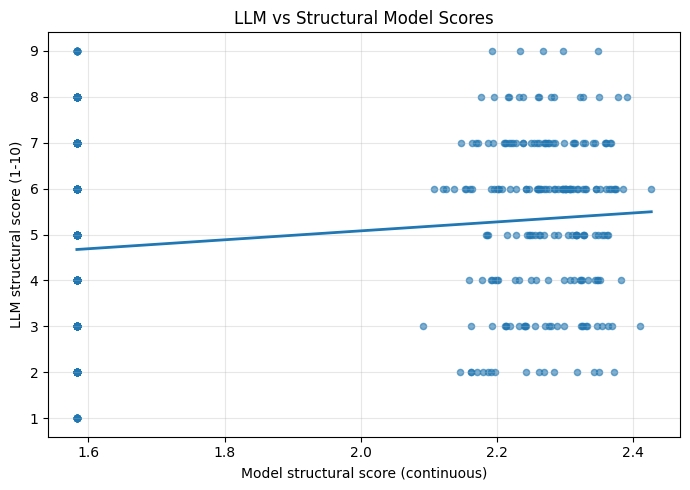

In [10]:
# Load ASQ LLM scoring results and run correlation analysis.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

asq_result_path = PROJECT_ROOT / 'data' / 'eval_results' / 'asq_random_1000_pair_LLM_structsim_scores.json'
if not asq_result_path.exists():
    raise FileNotFoundError(f'Result file not found: {asq_result_path}')

records = json.loads(asq_result_path.read_text(encoding='utf-8'))
if not isinstance(records, list):
    raise ValueError('Expected a list of result records in the JSON file.')

df_corr = pd.DataFrame(records)

required_cols = ['model_structural_score', 'llm_structural_score_1_to_10']
missing = [c for c in required_cols if c not in df_corr.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

# Keep only valid scored rows.
df_corr['model_structural_score'] = pd.to_numeric(df_corr['model_structural_score'], errors='coerce')
df_corr['llm_structural_score_1_to_10'] = pd.to_numeric(df_corr['llm_structural_score_1_to_10'], errors='coerce')

df_valid = df_corr.dropna(subset=['model_structural_score', 'llm_structural_score_1_to_10']).copy()

n_total = len(df_corr)
n_valid = len(df_valid)
n_errors = int(df_corr['llm_structural_score_1_to_10'].isna().sum())

print('Total records:', n_total)
print('Valid scored records:', n_valid)
print('Rows with missing LLM score (errors):', n_errors)

if n_valid < 3:
    raise ValueError('Not enough valid rows for correlation analysis (need at least 3).')

x = df_valid['model_structural_score'].to_numpy(dtype=float)
y = df_valid['llm_structural_score_1_to_10'].to_numpy(dtype=float)

pearson_r, pearson_p = pearsonr(x, y)
spearman_rho, spearman_p = spearmanr(x, y)

print('\nCorrelation results:')
print(f'Pearson r      = {pearson_r:.4f} (p={pearson_p:.4g})')
print(f'Spearman rho   = {spearman_rho:.4f} (p={spearman_p:.4g})')

# Optional: simple normalization view for interpretability only.
# LLM is on [1,10]; map to [0,1].
df_valid['llm_score_norm_0_1'] = (df_valid['llm_structural_score_1_to_10'] - 1.0) / 9.0

# Scatter plot with least-squares trendline.
plt.figure(figsize=(7.0, 5.0))
plt.scatter(x, y, alpha=0.6, s=20)

coef = np.polyfit(x, y, deg=1)
xx = np.linspace(x.min(), x.max(), 200)
yy = coef[0] * xx + coef[1]
plt.plot(xx, yy, linewidth=2)

plt.title('LLM vs Structural Model Scores')
plt.xlabel('Model structural score (continuous)')
plt.ylabel('LLM structural score (1-10)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
